In [ ]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from adjustText import adjust_text

In [6]:
raw_expressions = pd.read_csv('raw_expression_cells.tsv', sep='\t', index_col=0)

raw_expressions

,HCT_WT2,SW837D,R1-1,HCT_WT3,SW837,HCT116,HCT_WT1,SW620,R1-2,R1-3
ENSG00000223972,0,0,0,1,0,0,0,0,0,0
ENSG00000227232,84,5,0,141,51,150,142,196,0,2
ENSG00000278267,5,0,1,1,3,9,2,9,3,4
ENSG00000243485,0,0,0,0,0,0,0,0,0,0
ENSG00000284332,0,0,0,0,0,0,0,0,0,0
ENSG00000237613,0,0,0,0,0,0,0,0,0,0
ENSG00000268020,0,0,0,0,0,0,0,0,0,0
ENSG00000240361,0,0,0,0,0,0,0,0,0,0
ENSG00000186092,0,0,0,0,0,0,0,0,0,0
ENSG00000238009,2,0,1,2,0,7,4,4,0,0


In [7]:
raw_expressions.rename(columns = {'R1-1': 'HCT-15-4', 
                                     'R1-2': 'HCT-15-5',
                                     'R1-3': 'HCT-15-6',
                                     'HCT_WT1': 'HCT-15-1',
                                     'HCT_WT2': 'HCT-15-2',
                                     'HCT_WT3': 'HCT-15-3',
                                    }, inplace = True)

In [8]:
mean_gene_lenghts = pd.read_csv('gene_length.tsv', sep = '\t', index_col=0)['median_trna_lenght']
mean_gene_lenghts

Gene_id
ENSG00000223972    1140.0
ENSG00000227232    1340.0
ENSG00000278267      67.0
ENSG00000243485     621.0
ENSG00000284332     137.0
ENSG00000237613     886.0
ENSG00000268020     839.0
ENSG00000240361     939.0
ENSG00000186092     917.0
ENSG00000238009     626.0
ENSG00000239945    1317.0
ENSG00000233750    3811.0
ENSG00000268903     754.0
ENSG00000269981     283.0
ENSG00000239906     321.0
ENSG00000241860     904.0
ENSG00000222623     103.0
ENSG00000241599     455.0
ENSG00000279928     565.0
ENSG00000279457    1387.0
ENSG00000273874      67.0
ENSG00000228463    1290.0
ENSG00000241670     456.0
ENSG00000236679     384.0
ENSG00000236743     673.0
ENSG00000236601     605.0
ENSG00000237094     570.0
ENSG00000269732     362.0
ENSG00000278566     938.0
ENSG00000224813     182.0
                    ...  
ENSG00000276312      89.0
ENSG00000275757     152.0
ENSG00000273748     368.0
ENSG00000274202     112.0
ENSG00000278625     105.0
ENSG00000278573     601.0
ENSG00000276017    2403.0
ENSG

In [9]:
dataset_normalized = raw_expressions.copy()

for gene in dataset_normalized.index:
    dataset_normalized.loc[gene] = dataset_normalized.loc[gene]/mean_gene_lenghts[gene]*10**3
    
dataset_normalized = dataset_normalized.apply(lambda x: x/x.sum()*10**6)

dataset_normalized

,HCT-15-2,SW837D,HCT-15-4,HCT-15-3,SW837,HCT116,HCT-15-1,SW620,HCT-15-5,HCT-15-6
ENSG00000223972,0.000000,0.000000,0.000000,0.047122,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000227232,3.551290,0.615897,0.000000,5.652492,1.150944,3.039267,4.218097,3.913663,0.000000,0.114496
ENSG00000278267,4.227726,0.000000,1.007039,0.801772,1.354052,3.647120,1.188196,3.594180,3.292991,4.579826
ENSG00000243485,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000284332,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000237613,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000268020,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000240361,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000186092,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000238009,0.180995,0.000000,0.107782,0.171625,0.000000,0.303603,0.254342,0.170969,0.000000,0.000000


Text(0.5, 1.0, 'PCA of log(TPM) expression values')

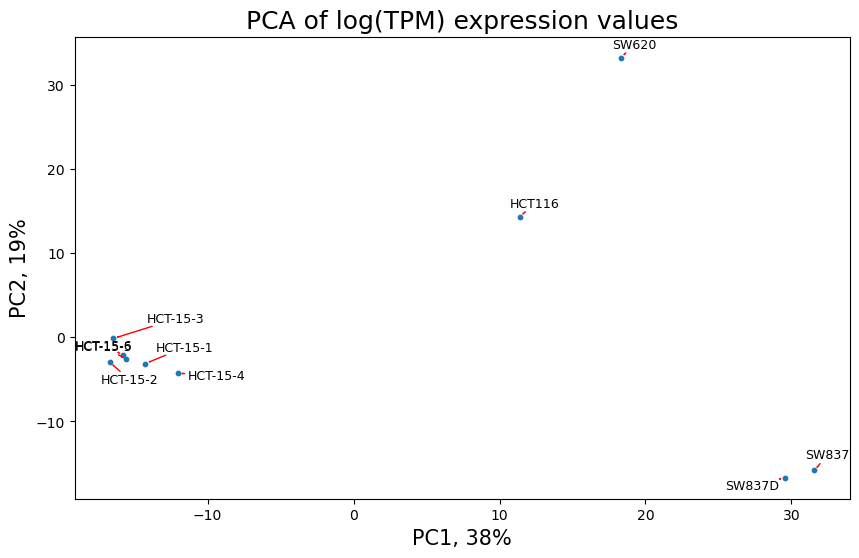

In [10]:
plt.figure(figsize=(10, 6))

pca = PCA(n_components=2)
pca_res = pca.fit_transform(dataset_normalized.applymap(lambda x: np.log10(x+1)).T).T
plt.scatter(pca_res[0], pca_res[1], s = 10)

expl_var = pca.explained_variance_ratio_

# Add labels and legend
plt.xlabel(f'PC1, {round(expl_var[0]*100)}%', fontsize=15)
plt.ylabel(f'PC2, {round(expl_var[1]*100)}%', fontsize=15)

annotations = []

for i, label in enumerate(dataset_normalized.columns):
    annotations.append(plt.text(pca_res[0][i], pca_res[1][i], label.split('_S')[0], fontsize=9, ha='right'))

adjust_text(annotations, expand=(1.2, 2), arrowprops=dict(arrowstyle='->', color='red'))

plt.title('PCA of log(TPM) expression values', fontsize=18)

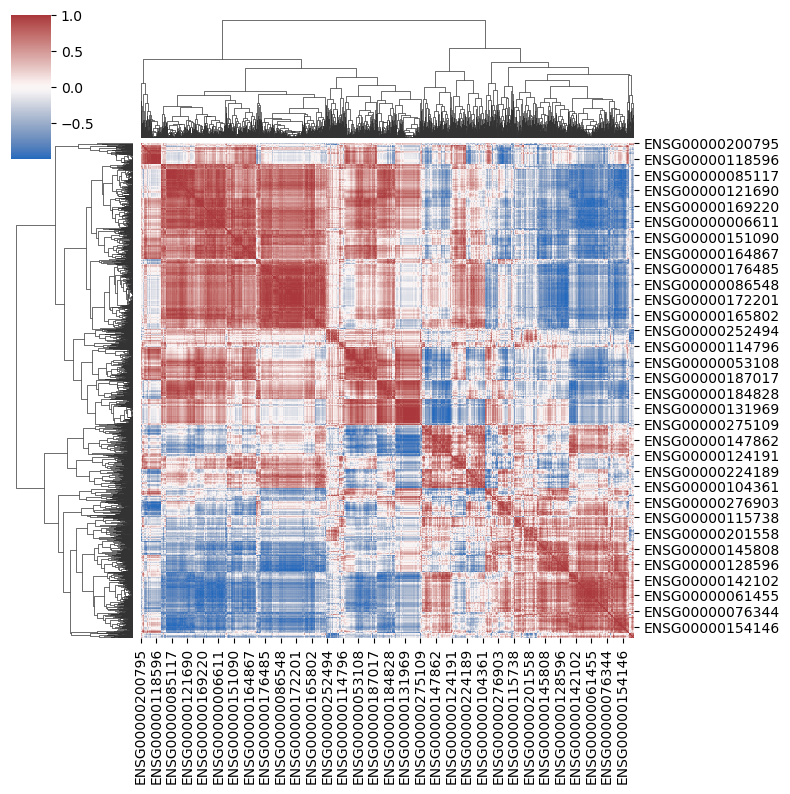

In [ ]:
data_log = dataset_normalized.applymap(lambda x: np.log10(x + 1))

top_genes = data_log.var(axis=1).sort_values(ascending=False).head(2000).index
data_top = data_log.loc[top_genes]

data_samples = data_top.T
corr = data_samples.corr(method="pearson")

sns.clustermap(
    corr,
    figsize=(8, 8),
    cmap="vlag",
    metric="euclidean",
    method="average"
)